In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import seaborn as sns
from pathlib import Path
import os
from os.path import join
import re
import math
from collections import OrderedDict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import RandomForestClassifier
# from sklearn.cluster import DBSCAN
from pyod.models.abod import ABOD
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.rod import ROD

from sklearn.utils import check_random_state
from sklearn.model_selection import ParameterSampler

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

import shap
import pickle
from joblib import Parallel, delayed

In [2]:
import warnings
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore", message="X has feature names, but IsolationForest was fitted without feature names")

# Coleta de Dados

In [3]:
MODULE_PATH = Path().absolute().parent
DATA_PATH = join(MODULE_PATH, "sources/processed")

In [4]:
complete_data = pd.read_csv(join(DATA_PATH, "complete_data_ground_truth.csv"))

In [5]:
complete_data

,ano,mes,data,precipitacao_total_soma,temperatura_bulbo_hora_media,temperatura_orvalho_hora_media,umidade_rel_hora_media,categoria_El Ninõ,categoria_La Ninã,categoria_Neutro,precipitacao_total_soma_outlier,temperatura_bulbo_hora_media_outlier,temperatura_orvalho_hora_media_outlier,umidade_rel_hora_media_outlier,total_outliers
0,2009,1,2009-01-01,3.417582,25.206729,20.251157,75.693584,0,1,0,0,0,0,0,0
1,2009,1,2009-01-02,6.923077,24.742439,20.038973,77.399546,0,1,0,0,0,0,0,0
2,2009,1,2009-01-03,10.432967,23.953602,19.699686,79.153908,0,1,0,1,0,0,0,1
3,2009,1,2009-01-04,5.701099,23.295086,18.676527,77.480558,0,1,0,0,0,0,0,0
4,2009,1,2009-01-05,5.127473,23.009149,17.906149,75.824475,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5839,2024,12,2024-12-27,5.853061,24.739027,19.652470,75.742225,0,1,0,0,0,0,0,0
5840,2024,12,2024-12-28,3.273469,25.208879,19.895573,74.673927,0,1,0,0,0,0,0,0
5841,2024,12,2024-12-29,5.895918,24.976626,19.863624,75.193482,0,1,0,0,0,0,0,0
5842,2024,12,2024-12-30,3.124490,25.026208,19.804128,74.833682,0,1,0,0,0,0,0,0


In [6]:
complete_data["data"] = pd.to_datetime(complete_data["data"])

In [7]:
complete_data = complete_data[complete_data.columns[:10].to_list() + ["total_outliers"]]

In [8]:
complete_data.head()

,ano,mes,data,precipitacao_total_soma,temperatura_bulbo_hora_media,temperatura_orvalho_hora_media,umidade_rel_hora_media,categoria_El Ninõ,categoria_La Ninã,categoria_Neutro,total_outliers
0,2009,1,2009-01-01,3.417582,25.206729,20.251157,75.693584,0,1,0,0
1,2009,1,2009-01-02,6.923077,24.742439,20.038973,77.399546,0,1,0,0
2,2009,1,2009-01-03,10.432967,23.953602,19.699686,79.153908,0,1,0,1
3,2009,1,2009-01-04,5.701099,23.295086,18.676527,77.480558,0,1,0,0
4,2009,1,2009-01-05,5.127473,23.009149,17.906149,75.824475,0,1,0,0


# Pré-Processamento

## Definição do Pipeline

In [9]:
feature_cols = complete_data.columns.tolist()[3:10]
numerical_cols = feature_cols[:-3]
categorical_cols = feature_cols[-3:]

In [10]:
def split_data(
    df: pd.DataFrame,
    year_cap: int = 2024,
    train_size: float = None):

    df = df.copy()

    if train_size is not None:
        df_train = df.iloc[:int(len(df)* 0.7)]
        df_test = df.iloc[int(len(df)* 0.7):]
        return df_train, df_test
    
    df_train = df[df["ano"] < year_cap]
    df_test = df[df["ano"] == year_cap]
    
    return df_train, df_test

In [11]:
def scale_data(
    df: pd.DataFrame, 
    columns: list[str]):

    df = df.copy()  
    
    scaler = StandardScaler()
    df[columns] = scaler.fit_transform(df[columns])
        
    return df

In [12]:
def create_residual_df(
    df: pd.DataFrame,
    numerical_cols: list[str],
    seasonal_period: int = 7):

    residual_df = df.copy()

    for col in numerical_cols:
        feature_decomposition = STL(residual_df[col], period=seasonal_period).fit()
        residual_df[col] = residual_df[col] - feature_decomposition.seasonal.values

    return residual_df

In [13]:
def create_ground_truth(
    df: pd.DataFrame,
    numerical_cols: list[str]):

    scaled_df = scale_data(df=df[numerical_cols], columns=numerical_cols)
    for col in scaled_df.columns:
        scaled_df[f'{col}_outlier'] = ((scaled_df[col] > 2) | (scaled_df[col] < -2))
        scaled_df[f'{col}_outlier'] = scaled_df[f'{col}_outlier'].astype(int)
    
    scaled_df["total_outliers"] = ((scaled_df > 2) | (scaled_df < -2)).sum(axis=1)

    ground_truth_cols = [col for col in scaled_df.columns.tolist() if col.endswith('_outlier') or col == 'total_outliers']
    ground_truth_data = scaled_df[ground_truth_cols]

    df[ground_truth_cols] = ground_truth_data

    return df

In [31]:
def bin_numerical_columns(
    data: pd.DataFrame, 
    numerical_cols: list[str], 
    bins: int, 
    labels: list[str]):

    df_binned = data.copy()
    for col in numerical_cols:
        df_binned[col + "_bin"] = pd.qcut(df_binned[col], q=bins, labels=labels)
    return df_binned

In [32]:
def preprocess_pipeline(
    df: pd.DataFrame,
    numerical_cols: list[str],
    normalize_data: bool = False,
    remove_seasonality: bool = False,
    seasonal_period: int = 7,
    year_cap: int = 2024,
    train_size: float = None,
    add_ground_truth: bool = False,
    binning: bool = False,
    bins: int = 4,
    bin_labels: list[str] = None): 

    df = df.copy()

    df_train, df_test = split_data(
        df=df, 
        year_cap=year_cap,
        train_size=train_size)
    if add_ground_truth:
        df_train = create_ground_truth(df=df_train, numerical_cols=numerical_cols)
        df_test = create_ground_truth(df=df_test, numerical_cols=numerical_cols)

    if remove_seasonality:
        df_train = create_residual_df(
            df=df_train, 
            numerical_cols=numerical_cols,
            seasonal_period=seasonal_period)

        df_test = create_residual_df(
            df=df_test, 
            numerical_cols=numerical_cols,
            seasonal_period=seasonal_period)
        
    if normalize_data:
        df_train = scale_data(df=df_train, columns=numerical_cols)
        df_test = scale_data(df=df_test, columns=numerical_cols)

    if binning:
        df_train = bin_numerical_columns(
            data=df_train, 
            numerical_cols=numerical_cols, 
            bins=bins, 
            labels=bin_labels)

        df_test = bin_numerical_columns(
            data=df_test, 
            numerical_cols=numerical_cols, 
            bins=bins, 
            labels=bin_labels)
    
    return df_train, df_test

In [15]:
df_train, df_test = preprocess_pipeline(
    df=complete_data,
    numerical_cols=numerical_cols,
    normalize_data=True,
    remove_seasonality=True,
    seasonal_period=7,
    year_cap=2024,
    add_ground_truth=False
)

In [16]:
df_train.head()

,ano,mes,data,precipitacao_total_soma,temperatura_bulbo_hora_media,temperatura_orvalho_hora_media,umidade_rel_hora_media,categoria_El Ninõ,categoria_La Ninã,categoria_Neutro,total_outliers
0,2009,1,2009-01-01,0.516595,0.518142,0.809336,0.705072,0,1,0,0
1,2009,1,2009-01-02,0.809228,0.496265,0.696057,0.574871,0,1,0,0
2,2009,1,2009-01-03,0.939321,0.350430,0.580991,0.568154,0,1,0,1
3,2009,1,2009-01-04,0.257438,0.227541,0.485380,0.509497,0,1,0,0
4,2009,1,2009-01-05,0.789362,0.069376,0.440880,0.647236,0,1,0,0


In [17]:
df_train.shape

(5478, 11)

In [18]:
df_test.head()

,ano,mes,data,precipitacao_total_soma,temperatura_bulbo_hora_media,temperatura_orvalho_hora_media,umidade_rel_hora_media,categoria_El Ninõ,categoria_La Ninã,categoria_Neutro,total_outliers
5478,2024,1,2024-01-01,2.528410,0.274112,0.919832,1.185001,1,0,0,1
5479,2024,1,2024-01-02,2.267235,0.336132,0.967832,1.206907,1,0,0,1
5480,2024,1,2024-01-03,2.227166,0.529365,1.031253,1.098778,1,0,0,2
5481,2024,1,2024-01-04,1.806127,0.567536,0.969393,0.956058,1,0,0,2
5482,2024,1,2024-01-05,1.617776,0.680945,0.978648,0.856082,1,0,0,0


In [19]:
df_test.shape

(366, 11)

In [20]:
def anomaly_detection_report(
    y_true: pd.Series,
    y_pred: pd.Series):

    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    precision = precision_score(y_true=y_true, y_pred=y_pred)
    recall = recall_score(y_true=y_true, y_pred=y_pred)
    f1 = f1_score(y_true=y_true, y_pred=y_pred)
    roc_auc = roc_auc_score(y_true=y_true, y_score=y_pred)
    
    return pd.DataFrame(
        {
            "accuracy": [accuracy],
            "precision": [precision],
            "recall": [recall],
            "f1": [f1],
            "roc_auc": [roc_auc]
        }
    )

In [21]:
def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    model_report = anomaly_detection_report(
        y_true=y_true,
        y_pred=y_pred)

    return f1_score(y_true, y_pred), model_report

In [22]:
def randomized_fine_tune_model(
    model_class: object, 
    param_distributions: dict, 
    X_train: pd.DataFrame, 
    X_test: pd.DataFrame, 
    y_test: pd.Series, 
    n_iter: int = 10, 
    n_jobs: int =-1, 
    random_state: int = None):
    
    rng = check_random_state(random_state)
    sampled_params = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=rng))

    def train_and_evaluate(params):
        try:
            model = model_class(**params).fit(X_train) 
            score, model_report = evaluate_model(model, X_test, y_test)
            return score, params, model, model_report
        except Exception as e:
            print(f"Erro com parâmetros {params}: {e}")
            return -np.inf, params, None, None

    results = Parallel(n_jobs=n_jobs)(
        delayed(train_and_evaluate)(params) for params in sampled_params
    )

    best_result = max(results, key=lambda x: x[0])
    best_score, best_params, best_model, best_report = best_result
    return best_model, best_params, best_score, best_report


In [24]:
with open(f'{MODULE_PATH}/explorations/artifacts/fine_tuning_results.pkl', 'rb') as f:
    results_dict = pickle.load(f)

In [25]:
results_dict

{'ABOD': {'model': ABOD(contamination=0.1, method='fast', n_neighbors=5),
  'params': {'n_neighbors': 5, 'method': 'fast'},
  'score': 0.5307692307692308,
  'normalize_data': False,
  'remove_seasonality': True,
  'model_report':    accuracy  precision    recall        f1   roc_auc
  0  0.666667   0.802326  0.396552  0.530769  0.654005},
 'IForest': {'model': IForest(behaviour='old', bootstrap=False, contamination=0.15,
      max_features=1.0, max_samples=0.8, n_estimators=200, n_jobs=1,
      random_state=None, verbose=0),
  'params': {'n_estimators': 200,
   'max_samples': 0.8,
   'contamination': 0.15,
   'bootstrap': False,
   'behaviour': 'old'},
  'score': 0.792332268370607,
  'normalize_data': False,
  'remove_seasonality': True,
  'model_report':    accuracy  precision    recall        f1   roc_auc
  0  0.822404   0.892086  0.712644  0.792332  0.817259},
 'LOF': {'model': LOF(algorithm='auto', contamination=0.15, leaf_size=30, metric='minkowski',
    metric_params=None, n_jobs=

In [26]:
results_dict["IForest"]

{'model': IForest(behaviour='old', bootstrap=False, contamination=0.15,
     max_features=1.0, max_samples=0.8, n_estimators=200, n_jobs=1,
     random_state=None, verbose=0),
 'params': {'n_estimators': 200,
  'max_samples': 0.8,
  'contamination': 0.15,
  'bootstrap': False,
  'behaviour': 'old'},
 'score': 0.792332268370607,
 'normalize_data': False,
 'remove_seasonality': True,
 'model_report':    accuracy  precision    recall        f1   roc_auc
 0  0.822404   0.892086  0.712644  0.792332  0.817259}

In [29]:
numerical_cols

['precipitacao_total_soma',
 'temperatura_bulbo_hora_media',
 'temperatura_orvalho_hora_media',
 'umidade_rel_hora_media']

# Treinamento com Binning

In [34]:
def fit_anomaly_detector(
    train_data: pd.DataFrame,
    model: object,
    params: dict = None):

    if params is not None:
        model = model(**params).fit(train_data)
    else:
        model = model().fit(train_data)

    if hasattr(model, "feature_importances_"):
        feature_importances = pd.DataFrame(
            model.feature_importances_,
            index=train_data.columns,
            columns=["importancia"]).sort_values("importancia", ascending=False)
    else:
        clf_model = RandomForestClassifier().fit(
            train_data, model.labels_)

        feature_importances = pd.DataFrame(
            clf_model.feature_importances_,
            index=train_data.columns,
            columns=["importancia"]).sort_values("importancia", ascending=False)
    
    return model, feature_importances

In [35]:
best_model_params = results_dict["IForest"]

df_train, df_test = preprocess_pipeline(
    df=complete_data,
    numerical_cols=numerical_cols,
    normalize_data=best_model_params["normalize_data"],
    remove_seasonality=best_model_params["remove_seasonality"],
    seasonal_period=7,
    year_cap=2024,
    add_ground_truth=False,
    binning=True,
    bins=4,
    bin_labels=["muito_baixo", "baixo", "alto", "muito_alto"]
)

feature_cols_binned = [col + "_bin" for col in numerical_cols] + [
    'categoria_El Ninõ', 'categoria_La Ninã', 'categoria_Neutro'
]

iforest_model, iforest_feature_importances = fit_anomaly_detector(
    train_data=pd.get_dummies(df_train[feature_cols_binned]),
    model=IForest,
    params=best_model_params["params"]
)

# Avaliação de Resultados

In [40]:
train_labels = np.where(df_train["total_outliers"] > 0, 1, 0)
test_labels = np.where(df_test["total_outliers"] > 0, 1, 0)

train_pred = iforest_model.labels_

test_pred = iforest_model.predict(pd.get_dummies(df_test[feature_cols_binned]))
test_anomaly_scores = iforest_model.decision_function(pd.get_dummies(df_test[feature_cols_binned]))

train_report = anomaly_detection_report(
    y_true=train_labels,
    y_pred=train_pred)
        
test_report = anomaly_detection_report(
    y_true=test_labels,
    y_pred=test_pred)

df_train["anomaly"] = train_pred
df_train["anomaly_score"] = iforest_model.decision_function(pd.get_dummies(df_train[feature_cols_binned]))
        

df_test["anomaly"] = test_pred
df_test["anomaly_score"] = test_anomaly_scores

In [41]:
train_report

,accuracy,precision,recall,f1,roc_auc
0,0.676342,0.216117,0.135321,0.166432,0.490682


In [42]:
test_report

,accuracy,precision,recall,f1,roc_auc
0,0.467213,0.285714,0.08046,0.125561,0.449084


In [43]:
def plot_confusion_matrices(results_dict: dict):
    """
    Plota matrizes de confusão 2 a 2 a partir de um dicionário com o nome do modelo como chave
    e uma tupla (y_true, y_pred) como valor.
    """
    n = len(results_dict)
    n_cols = 4
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten() 

    for idx, (model_name, (y_true, y_pred)) in enumerate(results_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(model_name)
        axes[idx].set_xlabel('Predito')
        axes[idx].set_ylabel('Real')

    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

In [44]:
def plot_feature_importances(feature_importance_dict: dict):

    n = len(feature_importance_dict)
    n_cols = 4
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten() 

    for idx, (model_name, feature_importance) in enumerate(feature_importance_dict.items()):
        sns.barplot(y=feature_importance.index, x=feature_importance["importancia"], ax=axes[idx])
        axes[idx].set_ylabel('Variável')
        axes[idx].set_title(model_name)

    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

## Resultados nos Dados de Treino

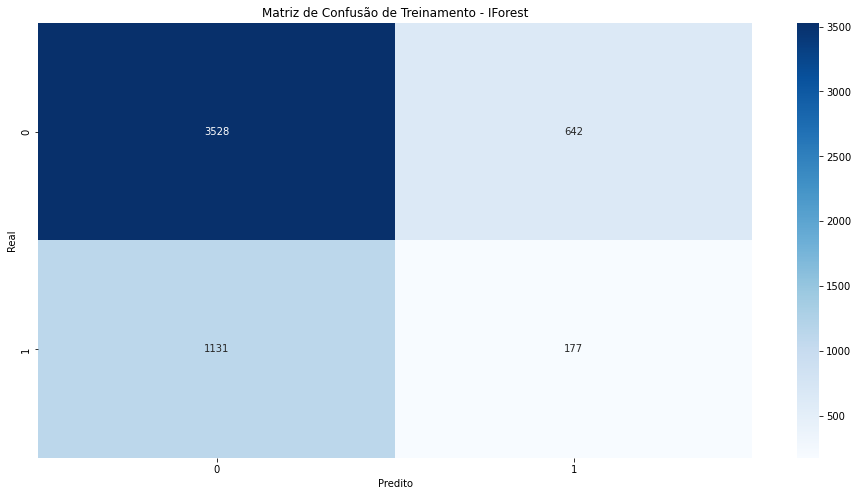

In [45]:
fig, ax = plt.subplots(figsize=(16, 8))
cm = confusion_matrix(train_labels, train_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão de Treinamento - IForest")
plt.xlabel("Predito")
plt.ylabel('Real')
plt.show()

## Resultados nos Dados de Teste

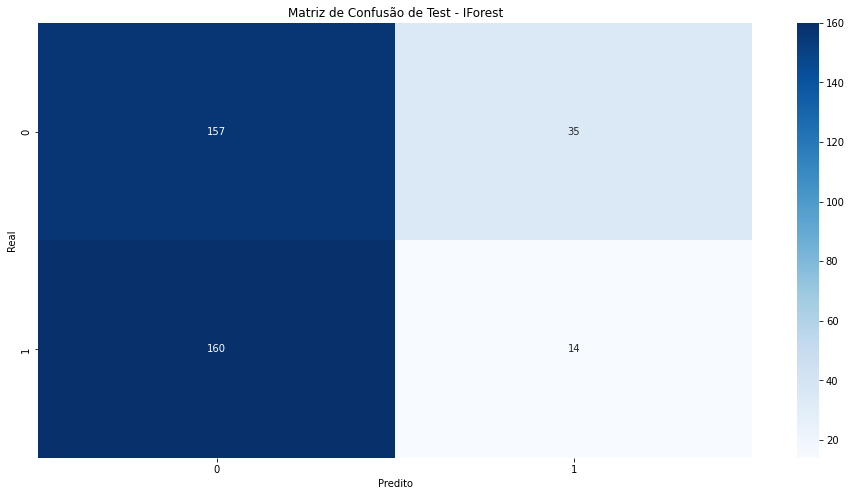

In [46]:
fig, ax = plt.subplots(figsize=(16, 8))
cm = confusion_matrix(test_labels, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão de Test - IForest")
plt.xlabel("Predito")
plt.ylabel('Real')
plt.show()

# Interpretação de Resultados

In [47]:
train_anomaly_perc = df_train.groupby(by=["ano"])["anomaly"].value_counts(normalize=True).reset_index()
train_anomaly_perc = train_anomaly_perc.loc[train_anomaly_perc["anomaly"] == 1].reset_index(drop=True)
train_anomaly_perc["dataset"] = "Dados de Treino"

In [48]:
train_anomaly_perc["proportion"].mean()

0.14952516405918606

In [49]:
test_anomaly_perc = df_test.groupby(by=["ano"])["anomaly"].value_counts(normalize=True).reset_index()
test_anomaly_perc = test_anomaly_perc.loc[test_anomaly_perc["anomaly"] == 1].reset_index(drop=True)
test_anomaly_perc["dataset"] = "Dados de Teste"

In [50]:
data_anomaly_perc = pd.concat([train_anomaly_perc, test_anomaly_perc], axis=0)

In [51]:
data_anomaly_perc.sort_values(by="proportion", ascending=False)

,ano,anomaly,proportion,dataset
6,2015,1,0.295890,Dados de Treino
14,2023,1,0.284932,Dados de Treino
3,2012,1,0.199454,Dados de Treino
10,2019,1,0.180822,Dados de Treino
0,2009,1,0.169863,Dados de Treino
5,2014,1,0.164384,Dados de Treino
4,2013,1,0.145205,Dados de Treino
0,2024,1,0.133880,Dados de Teste
2,2011,1,0.131507,Dados de Treino
13,2022,1,0.131507,Dados de Treino


In [52]:
yearly_data = complete_data.groupby("ano")[
    numerical_cols + ["categoria_El Ninõ", "categoria_La Ninã", "categoria_Neutro"]].mean()

In [53]:
yearly_data["indice_fenomenos"] = (
    yearly_data["categoria_El Ninõ"] - yearly_data["categoria_La Ninã"]) / (yearly_data["categoria_El Ninõ"] + yearly_data["categoria_La Ninã"])

In [54]:
index_data = yearly_data["indice_fenomenos"].reset_index()

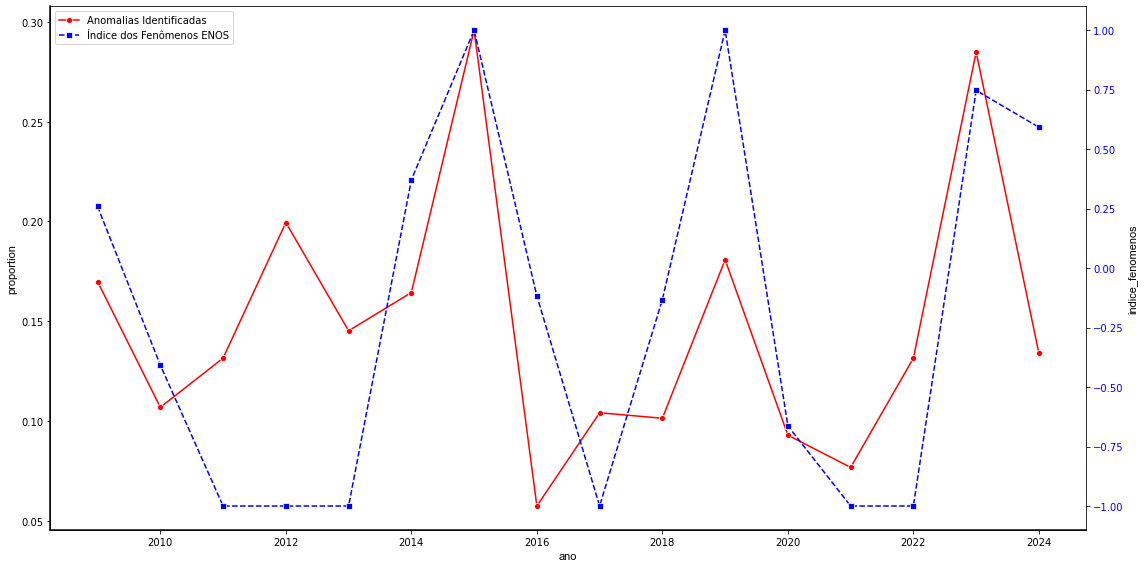

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 8))

# Linha do eixo primário
sns.lineplot(
    x=data_anomaly_perc["ano"],
    y=data_anomaly_perc["proportion"],
    marker="o",
    label="Anomalias Identificadas",
    ax=ax,
    color="red"
)

# Eixo secundário
ax2 = ax.twinx()
# Linha do eixo secundário SEM LABEL (temporariamente)
line2 = sns.lineplot(
    x=index_data["ano"],
    y=index_data["indice_fenomenos"],
    ax=ax2,
    color="blue",
    marker="s",
    linestyle="dashed"
)

# >>> Remover legenda automática do eixo secundário
# ax2.get_legend().remove()

# >>> Consolidar as legendas de ambos os eixos
handles1, labels1 = ax.get_legend_handles_labels()
# Crie manualmente o segundo item de legenda
handles2 = [line2.lines[0]]
labels2 = ["Índice dos Fenômenos ENOS"]
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

# >>> Formatação segundo as normas
ax.set_title('')
ax.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.5)

ax.set_xlabel("ano", fontsize=11, fontname="Arial", color="black")
ax.set_ylabel("proportion", fontsize=11, fontname="Arial", color="black")

ax2.set_ylabel("indice_fenomenos", fontsize=11, fontname="Arial", color="black")
ax2.tick_params(axis="y", labelcolor="blue")

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.show()


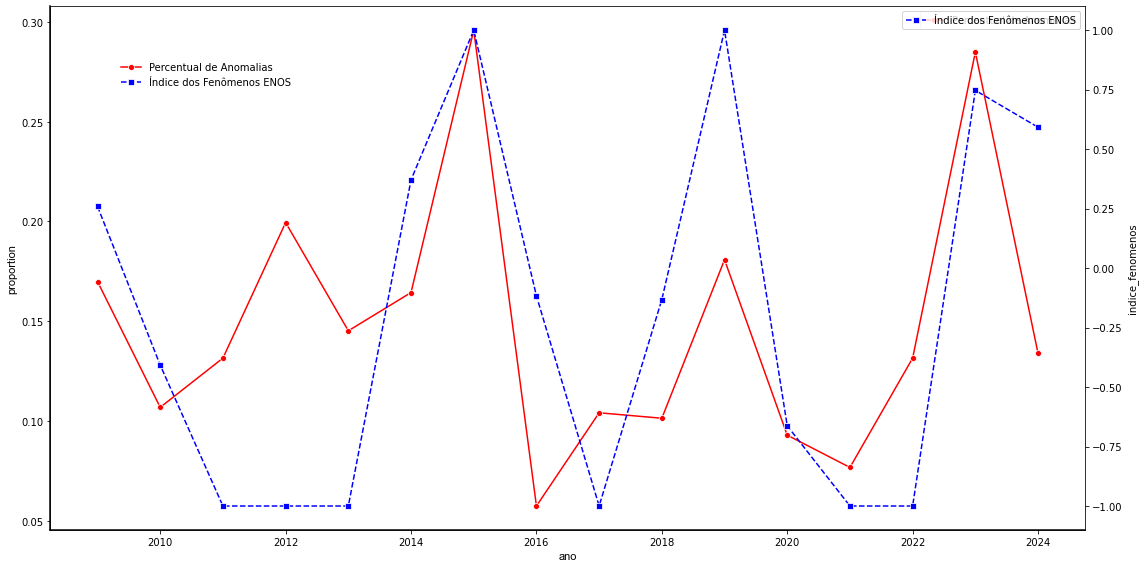

In [56]:
fig, ax = plt.subplots(figsize=(16, 8))

sns.lineplot(x=data_anomaly_perc["ano"], y=data_anomaly_perc["proportion"], marker="o", label="Percentual de Anomalias", ax=ax, color="red")
# sns.lineplot(x=test_anomaly_perc["ano"], y=test_anomaly_perc["proportion"], marker="o", label="Dados de Teste", ax=ax)

ax2 = ax.twinx()
sns.lineplot(
    x=index_data["ano"], 
    y=index_data["indice_fenomenos"], 
    ax=ax2,
    color="blue",
    marker="s",
    linestyle="dashed",
    label="Índice dos Fenômenos ENOS"
)

ax.set_title('')
ax.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.5)

ax.set_xlabel("ano", fontsize=11, fontname="Arial", color="black")
ax.set_ylabel("proportion", fontsize=11, fontname="Arial", color="black")

ax.set_facecolor("white")
fig.patch.set_facecolor("white")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), frameon=False)

plt.tight_layout()
plt.show()


In [57]:
test_anomaly_perc

,ano,anomaly,proportion,dataset
0,2024,1,0.13388,Dados de Teste


In [58]:
df_train["anomaly"].value_counts()

anomaly
0    4659
1     819
Name: count, dtype: int64

In [59]:
len(df_train)

5478

In [60]:
df_test["anomaly"].value_counts()

anomaly
0    317
1     49
Name: count, dtype: int64

In [61]:
len(df_test)

366

## Feature Importances

C:\Users\testd\AppData\Local\Temp\ipykernel_1036\1520904064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=iforest_feature_importances.sort_values(by="importancia", ascending=False)["importancia"].values, y=iforest_feature_importances.sort_values(by="importancia", ascending=False).index, palette="viridis")


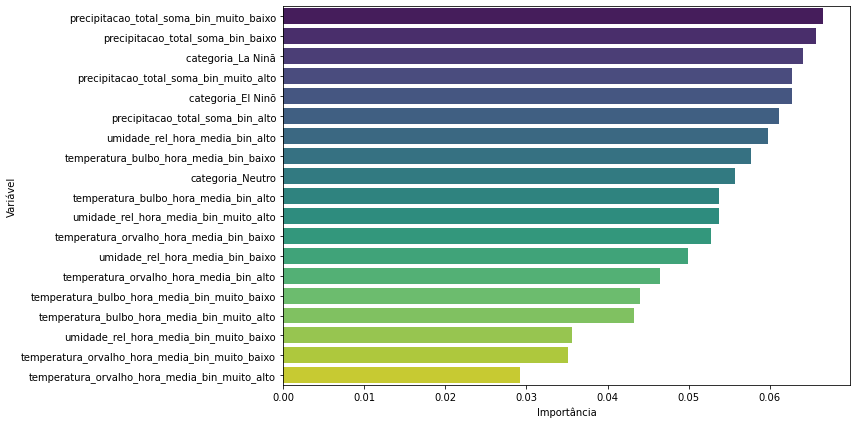

In [62]:
plt.figure(figsize=(12, 6))
sns.barplot(x=iforest_feature_importances.sort_values(by="importancia", ascending=False)["importancia"].values, y=iforest_feature_importances.sort_values(by="importancia", ascending=False).index, palette="viridis")
plt.xlabel("Importância")
plt.ylabel("Variável")
# plt.title("Importância das Features")
plt.tight_layout()
plt.show()